In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [3]:
figures_dir = repo_root / "figures"
reports_dir = repo_root / "reports"
data_path = repo_root / "data" / "processed" / "alsfrs_modeling_week5.csv"

figures_dir.mkdir(exist_ok=True)
reports_dir.mkdir(exist_ok=True)

In [4]:
patient_col = "subject_id"
target_col = "alsfrs_r_total"

modeling_df = pd.read_csv(data_path)
modeling_df.head(), modeling_df.shape

(   subject_id  alsfrs_delta  visit_number  baseline_alsfrs_r_total  \
 0        3301          40.0             2                     35.0   
 1        3301          98.0             3                     35.0   
 2        3301         161.0             4                     35.0   
 3        3301         221.0             5                     35.0   
 4        3301         273.0             6                     35.0   
 
    prev_alsfrs_r_total  time_since_first_visit  delta_from_prev_visit  age  \
 0                 35.0                    35.0                   35.0  NaN   
 1                 34.0                    93.0                   58.0  NaN   
 2                 32.0                   156.0                   63.0  NaN   
 3                 32.0                   216.0                   60.0  NaN   
 4                 34.0                   268.0                   52.0  NaN   
 
     sex  onset_delta site_of_onset  alsfrs_r_total  
 0  Male      -1049.0   Onset: Limb       

In [5]:
print(modeling_df.columns.tolist())

['subject_id', 'alsfrs_delta', 'visit_number', 'baseline_alsfrs_r_total', 'prev_alsfrs_r_total', 'time_since_first_visit', 'delta_from_prev_visit', 'age', 'sex', 'onset_delta', 'site_of_onset', 'alsfrs_r_total']


In [6]:
feature_cols = [
    col for col in modeling_df.columns
    if col not in [patient_col, target_col]
]

print("Feature columns:")
print(feature_cols)

Feature columns:
['alsfrs_delta', 'visit_number', 'baseline_alsfrs_r_total', 'prev_alsfrs_r_total', 'time_since_first_visit', 'delta_from_prev_visit', 'age', 'sex', 'onset_delta', 'site_of_onset']


In [7]:
train_df, test_df = train_test_split(
    modeling_df,
    test_size=0.2,
    random_state=42
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (36672, 12)
Test shape: (9169, 12)


In [8]:
X_train = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train = train_df[target_col].copy()
y_test = test_df[target_col].copy()

In [9]:
numeric_features = []
categorical_features = []

for col in feature_cols:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['alsfrs_delta', 'visit_number', 'baseline_alsfrs_r_total', 'prev_alsfrs_r_total', 'time_since_first_visit', 'delta_from_prev_visit', 'age', 'onset_delta']
Categorical features: ['sex', 'site_of_onset']


In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [11]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [12]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred, squared=False)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", round(rf_mae, 4))
print("Random Forest RMSE:", round(rf_rmse, 4))
print("Random Forest R^2:", round(rf_r2, 4))

Random Forest MAE: 1.8282
Random Forest RMSE: 2.5971
Random Forest R^2: 0.9134


In [13]:
results_df = X_test.copy()
results_df["actual_alsfrs_r_total"] = y_test.values
results_df["predicted_alsfrs_r_total"] = rf_pred
results_df["residual"] = results_df["actual_alsfrs_r_total"] - results_df["predicted_alsfrs_r_total"]
results_df["absolute_error"] = np.abs(results_df["residual"])

results_df.head()

,alsfrs_delta,visit_number,baseline_alsfrs_r_total,prev_alsfrs_r_total,time_since_first_visit,delta_from_prev_visit,age,sex,onset_delta,site_of_onset,actual_alsfrs_r_total,predicted_alsfrs_r_total,residual,absolute_error
9349,62.0,4,29.0,29.0,62.0,28.0,49.0,Male,-598.0,NaN,30.0,28.006362,1.993638,1.993638
34901,235.0,8,37.0,31.0,231.0,56.0,65.0,Female,-290.0,Onset: Bulbar,30.0,28.176327,1.823673,1.823673
27497,297.0,11,38.0,32.0,297.0,41.0,47.0,Male,-426.0,NaN,31.0,30.153477,0.846523,0.846523
14169,294.0,11,39.0,39.0,294.0,29.0,57.0,Male,-181.0,Onset: Other,37.0,38.023494,-1.023494,1.023494
33261,379.0,14,45.0,22.0,379.0,25.0,44.0,Male,NaN,Onset: Other,18.0,20.868233,-2.868233,2.868233


In [14]:
metrics_df = pd.DataFrame({
    "model_name": ["random_forest"],
    "mae": [rf_mae],
    "rmse": [rf_rmse],
    "r2": [rf_r2]
})

metrics_df

,model_name,mae,rmse,r2
0,random_forest,1.828223,2.597138,0.91344


In [15]:
metrics_output_path = reports_dir / "week9_rf_summary_metrics.csv"
metrics_df.to_csv(metrics_output_path, index=False)

metrics_output_path

PosixPath('/Users/danielkang/Desktop/DATS-4001-Capstone-Project/reports/week9_rf_summary_metrics.csv')

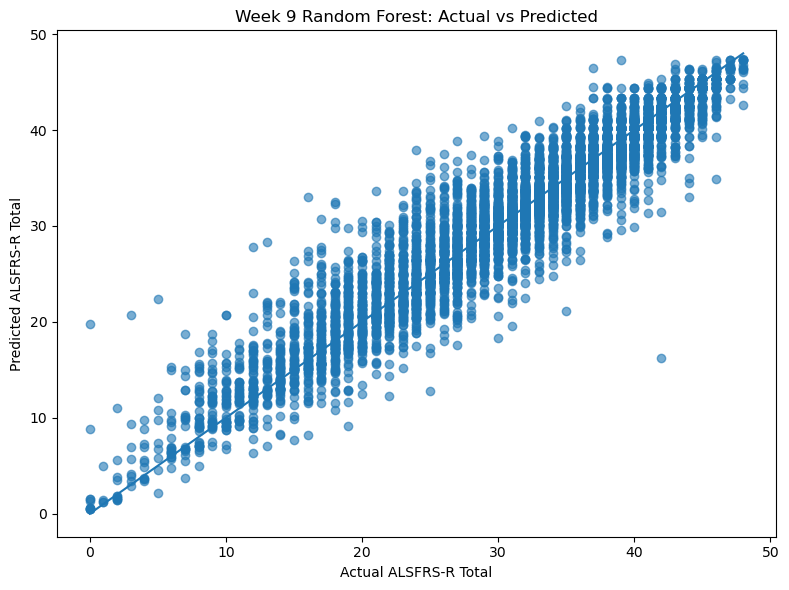

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(results_df["actual_alsfrs_r_total"], results_df["predicted_alsfrs_r_total"], alpha=0.6)

min_val = min(results_df["actual_alsfrs_r_total"].min(), results_df["predicted_alsfrs_r_total"].min())
max_val = max(results_df["actual_alsfrs_r_total"].max(), results_df["predicted_alsfrs_r_total"].max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual ALSFRS-R Total")
plt.ylabel("Predicted ALSFRS-R Total")
plt.title("Week 9 Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.savefig(figures_dir / "week9_actual_vs_predicted_rf.png", dpi=300, bbox_inches="tight")
plt.show()

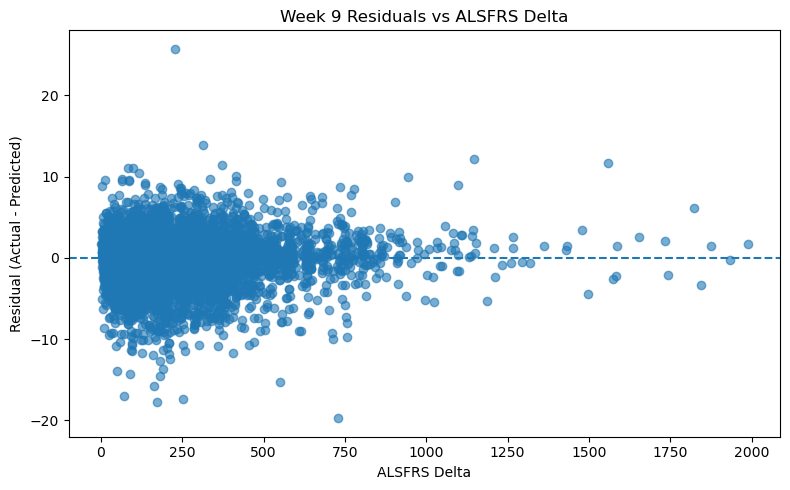

In [17]:
if "alsfrs_delta" in results_df.columns:
    plt.figure(figsize=(8, 5))
    plt.scatter(results_df["alsfrs_delta"], results_df["residual"], alpha=0.6)
    plt.axhline(0, linestyle="--")
    plt.xlabel("ALSFRS Delta")
    plt.ylabel("Residual (Actual - Predicted)")
    plt.title("Week 9 Residuals vs ALSFRS Delta")
    plt.tight_layout()
    plt.savefig(figures_dir / "week9_residuals_vs_delta_rf.png", dpi=300, bbox_inches="tight")
    plt.show()

In [18]:
results_df["alsfrs_delta_qbin"] = pd.qcut(
    results_df["alsfrs_delta"],
    q=4,
    duplicates="drop"
)

error_by_delta_qbin = (
    results_df.groupby("alsfrs_delta_qbin", observed=False)["absolute_error"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

error_by_delta_qbin.to_csv(
    reports_dir / "week9_error_by_delta_bin.csv",
    index=False
)

error_by_delta_qbin

,alsfrs_delta_qbin,mean,median,count
0,"(-0.001, 85.0]",1.584581,1.035023,2330
1,"(85.0, 165.0]",1.739028,1.162246,2257
2,"(165.0, 295.0]",2.008104,1.369702,2315
3,"(295.0, 1988.0]",1.983747,1.361223,2267


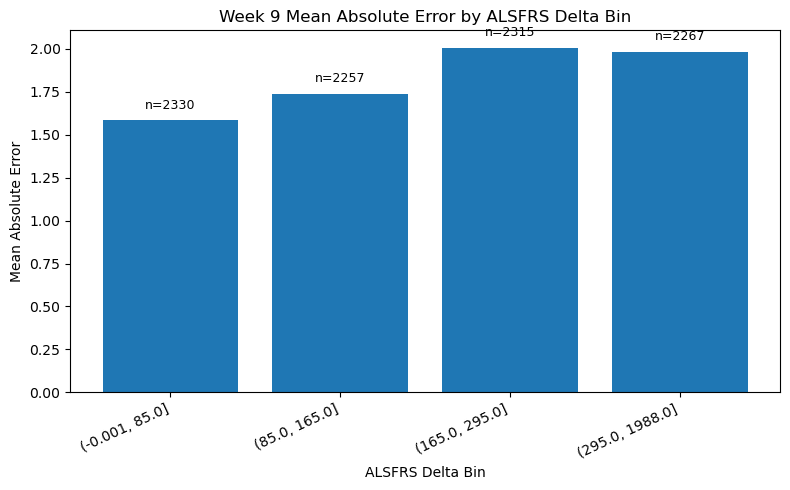

In [19]:
plt.figure(figsize=(8, 5))
bars = plt.bar(error_by_delta_qbin["alsfrs_delta_qbin"].astype(str), error_by_delta_qbin["mean"])

plt.xlabel("ALSFRS Delta Bin")
plt.ylabel("Mean Absolute Error")
plt.title("Week 9 Mean Absolute Error by ALSFRS Delta Bin")
plt.xticks(rotation=25, ha="right")

for i, row in error_by_delta_qbin.iterrows():
    plt.text(
        i,
        row["mean"] + 0.05,
        f'n={int(row["count"])}',
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.savefig(figures_dir / "week9_error_by_delta_bin.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
results_df["severity_group"] = pd.cut(
    results_df["actual_alsfrs_r_total"],
    bins=[0, 20, 35, 48],
    labels=["low_function", "moderate_function", "high_function"],
    include_lowest=True
)

results_df["severity_group"].value_counts(dropna=False)

severity_group
moderate_function    4327
high_function        3786
low_function         1056
Name: count, dtype: int64

In [21]:
error_by_severity = (
    results_df.groupby("severity_group", observed=False)["absolute_error"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

error_by_severity

,severity_group,mean,median,count
0,low_function,2.724319,1.812089,1056
1,moderate_function,1.982863,1.430486,4327
2,high_function,1.401544,0.919782,3786


In [22]:
error_by_severity_path = reports_dir / "week9_error_by_severity_group.csv"
error_by_severity.to_csv(error_by_severity_path, index=False)

error_by_severity_path

PosixPath('/Users/danielkang/Desktop/DATS-4001-Capstone-Project/reports/week9_error_by_severity_group.csv')

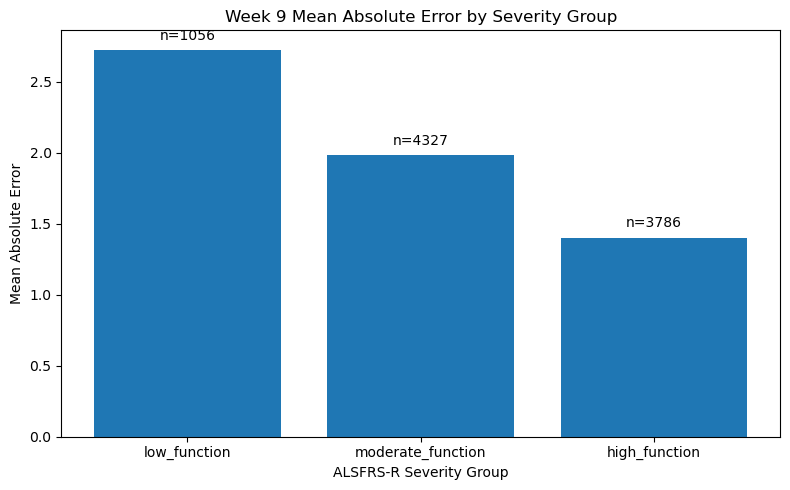

In [23]:
plt.figure(figsize=(8, 5))
bars = plt.bar(error_by_severity["severity_group"].astype(str), error_by_severity["mean"])

plt.xlabel("ALSFRS-R Severity Group")
plt.ylabel("Mean Absolute Error")
plt.title("Week 9 Mean Absolute Error by Severity Group")

for i, row in error_by_severity.iterrows():
    plt.text(
        i,
        row["mean"] + 0.05,
        f'n={int(row["count"])}',
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.savefig(figures_dir / "week9_error_by_severity_group.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
residual_bias_by_severity = (
    results_df.groupby("severity_group", observed=False)["residual"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

residual_bias_by_severity.to_csv(
    reports_dir / "week9_residual_bias_by_severity_group.csv",
    index=False
)

residual_bias_by_severity

,severity_group,mean,median,count
0,low_function,-1.563308,-0.963185,1056
1,moderate_function,-0.198264,0.088207,4327
2,high_function,0.637240,0.679978,3786


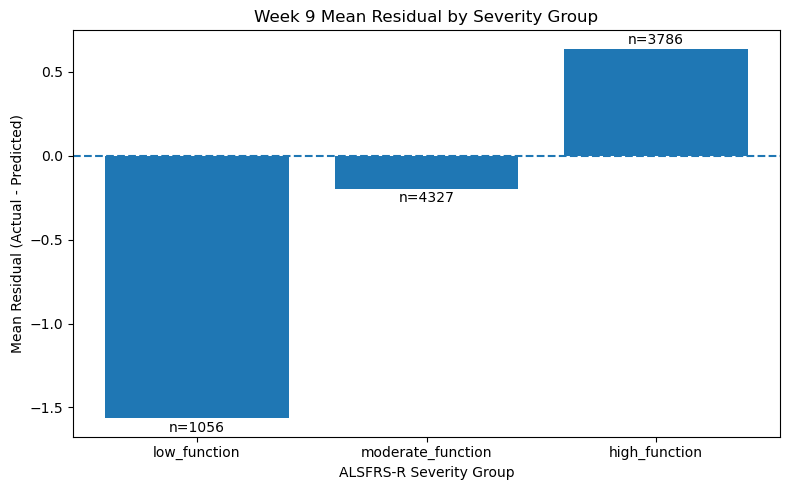

In [25]:
plt.figure(figsize=(8, 5))
bars = plt.bar(
    residual_bias_by_severity["severity_group"].astype(str),
    residual_bias_by_severity["mean"]
)

plt.axhline(0, linestyle="--")
plt.xlabel("ALSFRS-R Severity Group")
plt.ylabel("Mean Residual (Actual - Predicted)")
plt.title("Week 9 Mean Residual by Severity Group")

for i, row in residual_bias_by_severity.iterrows():
    plt.text(
        i,
        row["mean"] + 0.03 if row["mean"] >= 0 else row["mean"] - 0.08,
        f'n={int(row["count"])}',
        ha="center"
    )

plt.tight_layout()
plt.savefig(figures_dir / "week9_residual_bias_by_severity_group.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
worst_cases_df = results_df.sort_values("absolute_error", ascending=False).head(10)
worst_cases_df

,alsfrs_delta,visit_number,baseline_alsfrs_r_total,prev_alsfrs_r_total,time_since_first_visit,delta_from_prev_visit,age,sex,onset_delta,site_of_onset,actual_alsfrs_r_total,predicted_alsfrs_r_total,residual,absolute_error,alsfrs_delta_qbin,severity_group
5145,229.0,9,16.0,17.0,229.0,36.0,61.0,Female,-518.0,Onset: Other,42.0,16.265964,25.734036,25.734036,"(165.0, 295.0]",high_function
18181,728.0,3,33.0,26.0,728.0,637.0,58.0,Female,-674.0,Onset: Bulbar,0.0,19.743439,-19.743439,19.743439,"(295.0, 1988.0]",low_function
36264,173.0,7,33.0,22.0,173.0,33.0,68.0,Female,-551.0,Onset: Bulbar,3.0,20.754724,-17.754724,17.754724,"(165.0, 295.0]",low_function
44602,253.0,10,36.0,25.0,253.0,56.0,41.0,Male,-266.0,Onset: Limb,5.0,22.368542,-17.368542,17.368542,"(165.0, 295.0]",low_function
18834,71.0,4,37.0,34.0,71.0,31.0,65.0,Male,-523.0,Onset: Limb,16.0,33.015695,-17.015695,17.015695,"(-0.001, 85.0]",low_function
23,162.0,7,34.0,29.0,162.0,35.0,70.0,Male,-652.0,Onset: Limb,12.0,27.823614,-15.823614,15.823614,"(85.0, 165.0]",low_function
17280,550.0,5,46.0,34.0,550.0,189.0,50.0,Male,-504.0,Onset: Limb,13.0,28.290630,-15.290630,15.290630,"(295.0, 1988.0]",low_function
13664,182.0,4,41.0,34.0,176.0,63.0,58.0,Male,-697.0,NaN,18.0,32.494147,-14.494147,14.494147,"(165.0, 295.0]",low_function
10074,89.0,2,35.0,35.0,89.0,89.0,39.0,Female,NaN,Onset: Spine,18.0,32.299764,-14.299764,14.299764,"(85.0, 165.0]",low_function
1012,49.0,2,40.0,40.0,49.0,49.0,NaN,Female,-126.0,Onset: Bulbar,24.0,37.924541,-13.924541,13.924541,"(-0.001, 85.0]",moderate_function


In [27]:
worst_cases_path = reports_dir / "week9_worst_predicted_cases.csv"
worst_cases_df.to_csv(worst_cases_path, index=False)

worst_cases_path

PosixPath('/Users/danielkang/Desktop/DATS-4001-Capstone-Project/reports/week9_worst_predicted_cases.csv')